Aperçu du dataset :
   Row ID        Order ID Order Date  Ship Date       Ship Mode Customer ID  \
0       1  CA-2016-152156 2016-11-08 2016-11-11    Second Class    CG-12520   
1       2  CA-2016-152156 2016-11-08 2016-11-11    Second Class    CG-12520   
2       3  CA-2016-138688 2016-06-12 2016-06-16    Second Class    DV-13045   
3       4  US-2015-108966 2015-10-11 2015-10-18  Standard Class    SO-20335   
4       5  US-2015-108966 2015-10-11 2015-10-18  Standard Class    SO-20335   

     Customer Name    Segment        Country             City  ...  \
0      Claire Gute   Consumer  United States        Henderson  ...   
1      Claire Gute   Consumer  United States        Henderson  ...   
2  Darrin Van Huff  Corporate  United States      Los Angeles  ...   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   

  Postal Code  Region       Product ID         Category Sub-Category  \
0       4242

interactive(children=(Dropdown(description='Catégorie :', options=('All', 'Furniture', 'Office Supplies', 'Tec…


Répartition des ventes par pays :
Country
United States    2.297201e+06
Name: Sales, dtype: float64


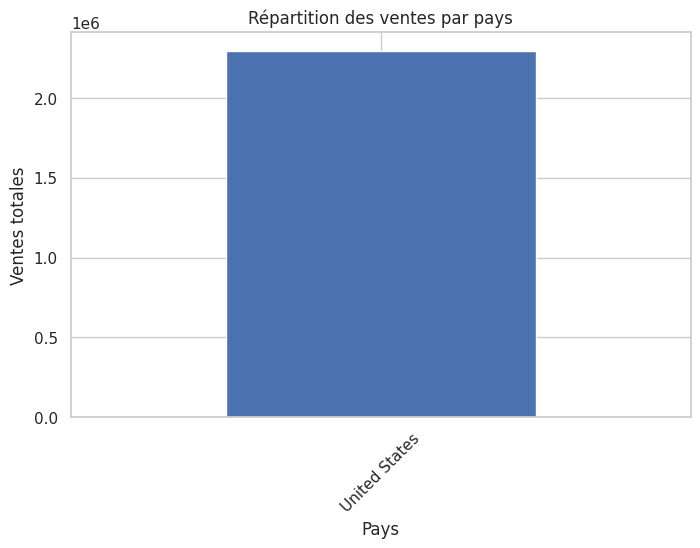

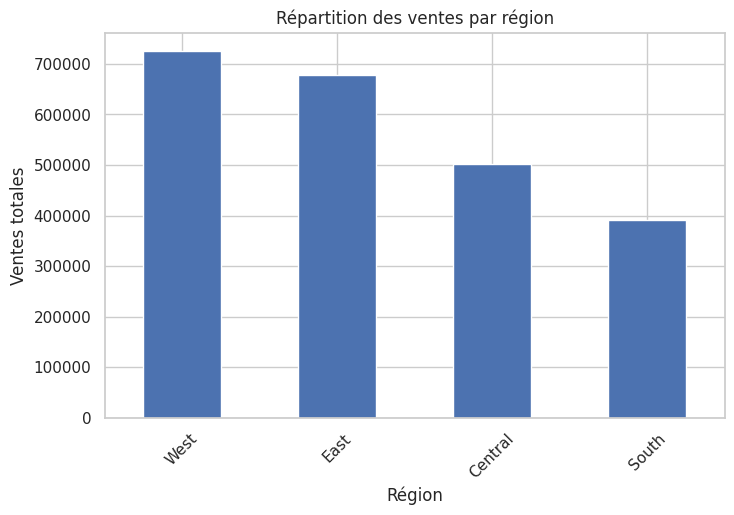

/tmp/ipykernel_818/372789460.py:122: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


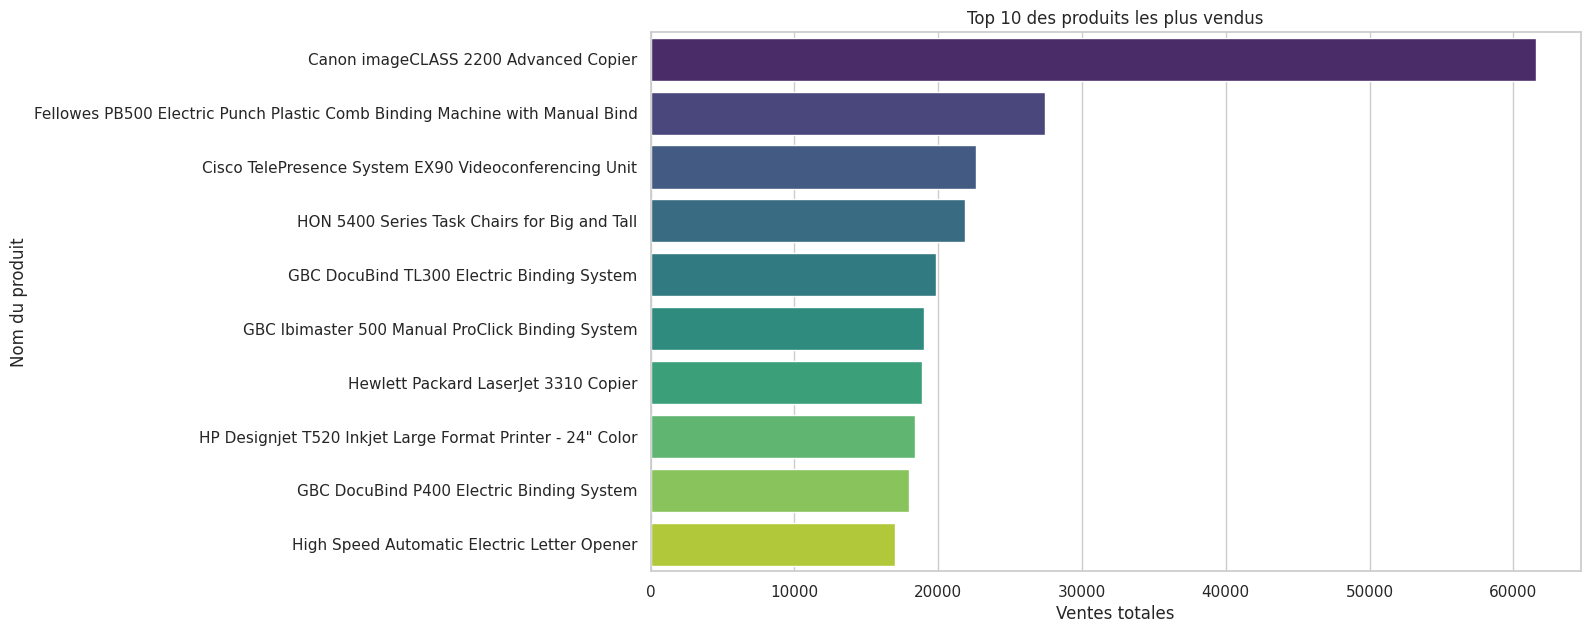


Top 10 des produits les plus vendus :
Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64


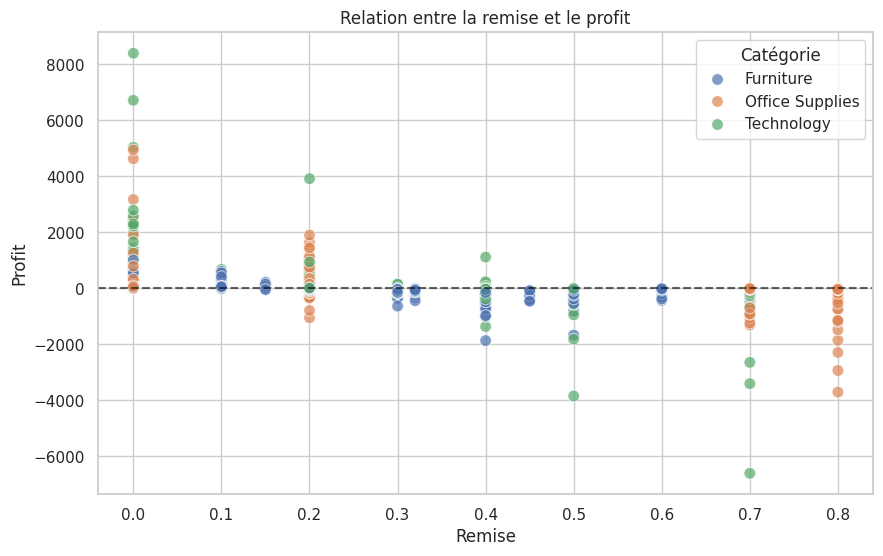


Statistiques sur les remises :
count    9994.000000
mean        0.156203
std         0.206452
min         0.000000
25%         0.000000
50%         0.200000
75%         0.200000
max         0.800000
Name: Discount, dtype: float64

Statistiques sur les profits :
count    9994.000000
mean       28.656896
std       234.260108
min     -6599.978000
25%         1.728750
50%         8.666500
75%        29.364000
max      8399.976000
Name: Profit, dtype: float64

Analyse des transactions avec une remise supérieure à 20% :
Nombre de transactions : 1393
Profit moyen : -97.18309834888733
Pourcentage de transactions en perte : 96.76956209619526 %

 ANALYSE COMPARATIVE 

Matplotlib :
- Matplotlib est très flexible pour créer des graphiques personnalisés.
- Il est utile pour créer des graphiques interactifs avec ipywidgets.
- Il demande parfois plus de code pour obtenir un graphique esthétique.

Seaborn :
- Seaborn permet de créer rapidement des graphiques plus élégants.
- Il est très pratique pour

In [3]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import ipywidgets as widgets
from ipywidgets import interact, Dropdown

sns.set(style="whitegrid")


file_path = "/content/US Superstore data (1).xls"

df = pd.read_excel(file_path)

print("Aperçu du dataset :")
print(df.head())

print("\nDimensions du dataset :")
print(df.shape)

print("\nColonnes du dataset :")
print(df.columns)

print("\nInformations générales :")
print(df.info())


df.columns = df.columns.str.strip()

print("\nNombre de doublons avant suppression :", df.duplicated().sum())

df = df.drop_duplicates()

print("Nombre de doublons après suppression :", df.duplicated().sum())

print("\nValeurs manquantes par colonne :")
print(df.isnull().sum())

if "Postal Code" in df.columns:
    df["Postal Code"] = df["Postal Code"].fillna(0)

df["Order Date"] = pd.to_datetime(df["Order Date"], errors="coerce")
df["Ship Date"] = pd.to_datetime(df["Ship Date"], errors="coerce")

df = df.dropna(subset=["Order Date"])

df["Order Year"] = df["Order Date"].dt.year
df["Order Month"] = df["Order Date"].dt.month
df["Order Month-Year"] = df["Order Date"].dt.to_period("M")

print("\nAperçu après nettoyage :")
print(df.head())


yearly_sales_category = df.groupby(["Order Year", "Category"])["Sales"].sum().reset_index()

def plot_sales_trend(category="All"):
    plt.figure(figsize=(10, 5))

    if category == "All":
        yearly_sales = df.groupby("Order Year")["Sales"].sum()
        plt.plot(
            yearly_sales.index,
            yearly_sales.values,
            marker="o",
            linewidth=2
        )
        plt.title("Tendance des ventes au fil des années - Toutes catégories")
    else:
        filtered_data = yearly_sales_category[yearly_sales_category["Category"] == category]
        plt.plot(
            filtered_data["Order Year"],
            filtered_data["Sales"],
            marker="o",
            linewidth=2
        )
        plt.title(f"Tendance des ventes au fil des années - {category}")

    plt.xlabel("Année")
    plt.ylabel("Ventes totales")
    plt.grid(True)
    plt.show()

categories = ["All"] + list(df["Category"].dropna().unique())

interact(
    plot_sales_trend,
    category=Dropdown(options=categories, value="All", description="Catégorie :")
)

country_sales = df.groupby("Country")["Sales"].sum().sort_values(ascending=False)

print("\nRépartition des ventes par pays :")
print(country_sales)

plt.figure(figsize=(8, 5))
country_sales.plot(kind="bar")

plt.title("Répartition des ventes par pays")
plt.xlabel("Pays")
plt.ylabel("Ventes totales")
plt.xticks(rotation=45)
plt.show()

region_sales = df.groupby("Region")["Sales"].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
region_sales.plot(kind="bar")

plt.title("Répartition des ventes par région")
plt.xlabel("Région")
plt.ylabel("Ventes totales")
plt.xticks(rotation=45)
plt.show()


top_products = df.groupby("Product Name")["Sales"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 7))

sns.barplot(
    x=top_products.values,
    y=top_products.index,
    palette="viridis"
)

plt.title("Top 10 des produits les plus vendus")
plt.xlabel("Ventes totales")
plt.ylabel("Nom du produit")
plt.show()

print("\nTop 10 des produits les plus vendus :")
print(top_products)


plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="Discount",
    y="Profit",
    hue="Category",
    alpha=0.7,
    s=70
)

plt.axhline(y=0, color="black", linestyle="--", alpha=0.6)

plt.title("Relation entre la remise et le profit")
plt.xlabel("Remise")
plt.ylabel("Profit")
plt.legend(title="Catégorie")
plt.grid(True)
plt.show()

print("\nStatistiques sur les remises :")
print(df["Discount"].describe())

print("\nStatistiques sur les profits :")
print(df["Profit"].describe())

high_discount = df[df["Discount"] > 0.2]

print("\nAnalyse des transactions avec une remise supérieure à 20% :")
print("Nombre de transactions :", len(high_discount))
print("Profit moyen :", high_discount["Profit"].mean())
print("Pourcentage de transactions en perte :", (high_discount["Profit"] < 0).mean() * 100, "%")


print("\n ANALYSE COMPARATIVE ")

print("\nMatplotlib :")
print("- Matplotlib est très flexible pour créer des graphiques personnalisés.")
print("- Il est utile pour créer des graphiques interactifs avec ipywidgets.")
print("- Il demande parfois plus de code pour obtenir un graphique esthétique.")

print("\nSeaborn :")
print("- Seaborn permet de créer rapidement des graphiques plus élégants.")
print("- Il est très pratique pour les analyses statistiques.")
print("- Il gère facilement les couleurs, les catégories et les tendances visuelles.")

print("\nObservation :")
print("Matplotlib est plus adapté lorsque l'on veut contrôler chaque détail du graphique.")
print("Seaborn est plus efficace pour produire rapidement des visualisations claires et professionnelles.")


total_sales = df["Sales"].sum()
total_profit = df["Profit"].sum()
top_product_name = top_products.index[0]
top_product_sales = top_products.iloc[0]

print("\n RÉSUMÉ FINAL ")

print(f"Chiffre d'affaires total : {total_sales:,.2f}")
print(f"Profit total : {total_profit:,.2f}")
print(f"Produit le plus vendu : {top_product_name}")
print(f"Ventes du produit le plus vendu : {top_product_sales:,.2f}")

print("\nPrincipales observations :")
print("1. Les ventes peuvent être analysées dans le temps grâce au graphique linéaire interactif.")
print("2. La répartition des ventes par pays montre que le dataset est principalement centré sur les États-Unis.")
print("3. L'analyse par région permet d'avoir une meilleure vision géographique des ventes.")
print("4. Le graphique des produits les plus vendus permet d'identifier les produits importants pour l'entreprise.")
print("5. Le nuage de points montre que les fortes remises peuvent être associées à des profits plus faibles ou négatifs.")

print("\nConclusion :")
print("Cette analyse montre que Matplotlib et Seaborn sont complémentaires.")
print("Matplotlib est utile pour les graphiques personnalisés et interactifs.")
print("Seaborn est plus pratique pour les visualisations statistiques et professionnelles.")